In [1]:
#no labels on the drug protein embeddings just to note
import pickle
import numpy as np

file_path = "drug_protein_embeddings.pkl"

with open(file_path, "rb") as f:
    data = pickle.load(f)

print("Type of loaded object:", type(data))

# # Convert dict → matrix
embeddings = np.array(list(data.values()))
# keys = list(data.keys())

# print("Shape:", embeddings.shape)   # (N, 1024)
# print("NaNs:", np.isnan(embeddings).sum())
# print("Infs:", np.isinf(embeddings).sum())

# norms = np.linalg.norm(embeddings, axis=1)

# print("Min norm:", norms.min())
# print("Max norm:", norms.max())
# print("Mean norm:", norms.mean())

# variance = np.var(embeddings, axis=0)

# print("Mean variance across dimensions:", variance.mean())
# print("Zero-variance dims:", np.sum(variance == 0))

Type of loaded object: <class 'dict'>


Shape: (644, 1024)

--- Norm Stats ---
Mean norm: 0.0
Std norm: 0.0
Min norm: 0.0
Max norm: 0.0

--- Zero Vector Check ---
Zero embeddings: 644
Percentage: 1.0

--- Cosine Similarity ---
Mean: 0.0
Std: 0.0
Min: 0.0
Max: 0.0

--- Uniqueness ---
Unique embeddings: 1
Total embeddings: 644


c:\Users\DELL\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\decomposition\_pca.py:685: RuntimeWarning: invalid value encountered in divide
  self.explained_variance_ratio_ = self.explained_variance_ / total_var


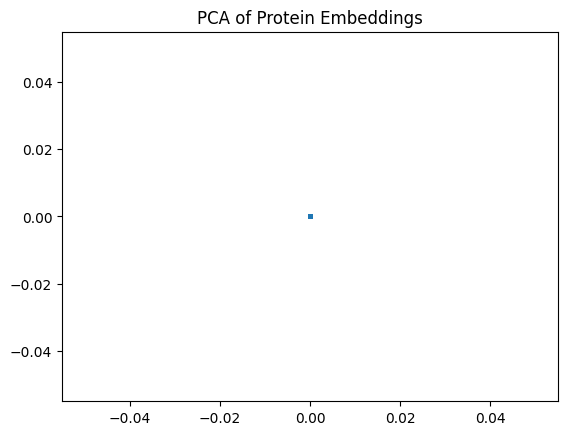

In [2]:
import pickle
import numpy as np
import torch
import torch.nn.functional as F
from sklearn.metrics.pairwise import cosine_similarity

# =========================
# LOAD EMBEDDINGS
# =========================
with open("drug_protein_embeddings.pkl", "rb") as f:
    emb_dict = pickle.load(f)

embs = np.stack(list(emb_dict.values()))   # shape (N, 1024)

print("Shape:", embs.shape)

# =========================
# 1. NORM STATS
# =========================
norms = np.linalg.norm(embs, axis=1)

print("\n--- Norm Stats ---")
print("Mean norm:", norms.mean())
print("Std norm:", norms.std())
print("Min norm:", norms.min())
print("Max norm:", norms.max())

# =========================
# 2. ZERO VECTOR CHECK (CRITICAL)
# =========================
zero_mask = norms == 0
num_zero = np.sum(zero_mask)

print("\n--- Zero Vector Check ---")
print("Zero embeddings:", num_zero)
print("Percentage:", num_zero / len(embs))

# =========================
# 3. COSINE SIMILARITY (sampled)
# =========================
idx = np.random.choice(len(embs), size=min(500, len(embs)), replace=False)
sample = embs[idx]

sample = sample / (np.linalg.norm(sample, axis=1, keepdims=True) + 1e-8)
sims = sample @ sample.T

upper = sims[np.triu_indices_from(sims, k=1)]

print("\n--- Cosine Similarity ---")
print("Mean:", upper.mean())
print("Std:", upper.std())
print("Min:", upper.min())
print("Max:", upper.max())

# =========================
# 4. DUPLICATE CHECK
# =========================
unique_rows = np.unique(embs, axis=0)

print("\n--- Uniqueness ---")
print("Unique embeddings:", len(unique_rows))
print("Total embeddings:", len(embs))

# =========================
# 5. OPTIONAL PCA VISUALIZATION
# =========================
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

X = embs[:1000]  # sample

pca = PCA(n_components=2)
X_2d = pca.fit_transform(X)

plt.scatter(X_2d[:,0], X_2d[:,1], s=5)
plt.title("PCA of Protein Embeddings")
plt.show()